In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("data_coffeeshop.csv")
df.head()


,Year of Start,Current State,Size of Site
0,2008.0,In,20.80
1,2010.0,In,212.72
2,2013.0,In,20.04
3,2012.0,In,64.17
4,2002.0,Out,11.40


In [5]:
print("Total rows:", len(df))
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.info()

Total rows: 43182

Missing values:
 Year of Start    19
Current State    19
Size of Site     19
dtype: int64

Duplicate rows: 11747
<class 'pandas.DataFrame'>
RangeIndex: 43182 entries, 0 to 43181
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year of Start  43163 non-null  float64
 1   Current State  43163 non-null  str    
 2   Size of Site   43163 non-null  float64
dtypes: float64(2), str(1)
memory usage: 1012.2 KB


In [6]:
df['duplicate_flag'] = df.duplicated().map({True: 'Yes', False: 'No'})
print("Duplicate flag added")
print(df['duplicate_flag'].value_counts())

Duplicate flag added
duplicate_flag
No     31435
Yes    11747
Name: count, dtype: int64


In [7]:
before = len(df)
df = df.drop_duplicates(subset=['Year of Start', 'Current State', 'Size of Site'], keep='first')
after = len(df)
print(f"Rows before: {before}")
print(f"Rows after removing duplicates: {after}")
print(f"Removed {before - after} duplicate rows")

Rows before: 43182
Rows after removing duplicates: 31435
Removed 11747 duplicate rows


In [8]:
# Size of Site: missing values ko median se fill karo
df['Size of Site'] = df['Size of Site'].fillna(df['Size of Site'].median())

# Current State: missing rows ko drop karo (category hai, guess nahi kar sakte)
df = df.dropna(subset=['Current State'])

# Year of Start: missing rows drop karo
df = df.dropna(subset=['Year of Start'])

# Check karo ab kitne missing values bache
print("Missing values ab:\n", df.isnull().sum())
print("\nTotal rows ab:", len(df))

Missing values ab:
 Year of Start     0
Current State     0
Size of Site      0
duplicate_flag    0
dtype: int64

Total rows ab: 31434


In [9]:
print("Current State ki unique values:", df['Current State'].unique())

# Sirf 'In' aur 'Out' wali rows rakho
df = df[df['Current State'].isin(['In', 'Out'])]

print("\nFilter ke baad total rows:", len(df))
print("Current State ki unique values ab:", df['Current State'].unique())

Current State ki unique values: <StringArray>
['In', 'Out']
Length: 2, dtype: str

Filter ke baad total rows: 31434
Current State ki unique values ab: <StringArray>
['In', 'Out']
Length: 2, dtype: str


In [10]:
def size_category(size):
    if size < 50:
        return 'Small'
    elif size <= 500:
        return 'Medium'
    else:
        return 'Large'

df['Size Category'] = df['Size of Site'].apply(size_category)

print(df[['Size of Site', 'Size Category']].head(10))
print("\nSize Category distribution:\n", df['Size Category'].value_counts())

   Size of Site Size Category
0         20.80         Small
1        212.72        Medium
2         20.04         Small
3         64.17        Medium
4         11.40         Small
5         10.99         Small
6         67.50        Medium
7         46.05         Small
8          8.20         Small
9         39.92         Small

Size Category distribution:
 Size Category
Medium    18234
Small     13098
Large       102
Name: count, dtype: int64


Total outliers found: 2142
Outlier limit range: -84.94125 to 229.72875


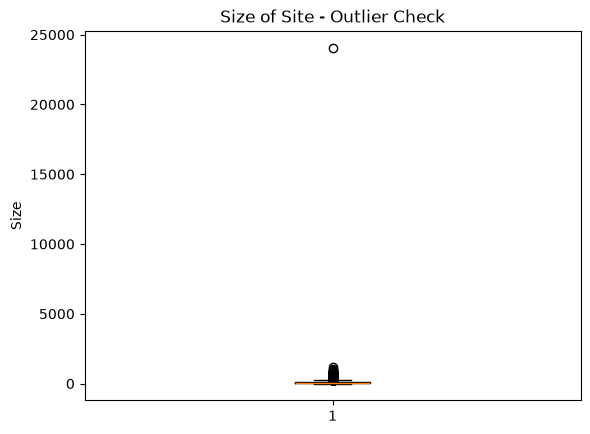

In [11]:
Q1 = df['Size of Site'].quantile(0.25)
Q3 = df['Size of Site'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['is_outlier'] = (df['Size of Site'] < lower_limit) | (df['Size of Site'] > upper_limit)

print("Total outliers found:", df['is_outlier'].sum())
print("Outlier limit range:", lower_limit, "to", upper_limit)

plt.boxplot(df['Size of Site'])
plt.title('Size of Site - Outlier Check')
plt.ylabel('Size')
plt.show()

In [12]:
df.rename(columns={
    'Year of Start': 'year_of_start',
    'Current State': 'current_state',
    'Size of Site': 'size_of_site',
    'Size Category': 'size_category'
}, inplace=True)

df['year_of_start'] = df['year_of_start'].astype(int)

print(df.dtypes)
print("\n")
print(df.head())

year_of_start       int64
current_state         str
size_of_site      float64
duplicate_flag        str
size_category         str
is_outlier           bool
dtype: object


   year_of_start current_state  size_of_site duplicate_flag size_category  \
0           2008            In         20.80             No         Small   
1           2010            In        212.72             No        Medium   
2           2013            In         20.04             No         Small   
3           2012            In         64.17             No        Medium   
4           2002           Out         11.40             No         Small   

   is_outlier  
0       False  
1       False  
2       False  
3       False  
4       False  


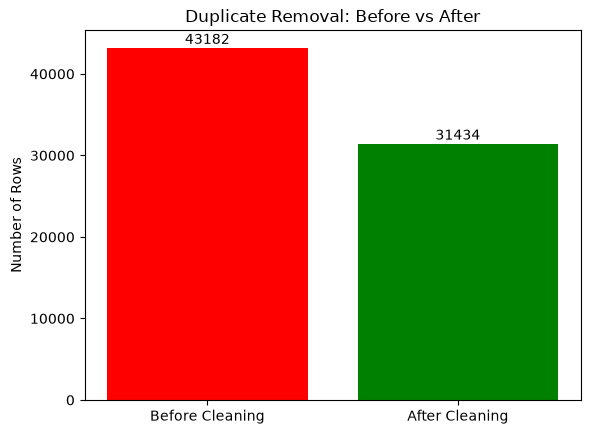

In [13]:
labels = ['Before Cleaning', 'After Cleaning']
values = [43182, len(df)]

plt.bar(labels, values, color=['red', 'green'])
plt.title('Duplicate Removal: Before vs After')
plt.ylabel('Number of Rows')
for i, v in enumerate(values):
    plt.text(i, v + 500, str(v), ha='center')
plt.show()

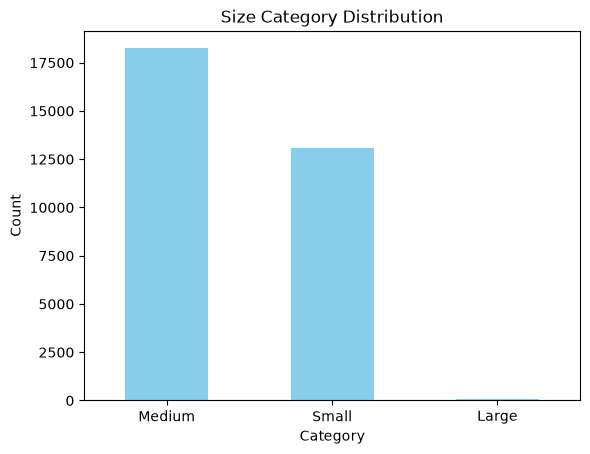

In [14]:
df['size_category'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Size Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [15]:
df.to_csv("coffeeshop_cleaned.csv", index=False)
print("Saved! Final cleaned dataset has", len(df), "rows and", len(df.columns), "columns")
print("\nFinal columns:", list(df.columns))

Saved! Final cleaned dataset has 31434 rows and 6 columns

Final columns: ['year_of_start', 'current_state', 'size_of_site', 'duplicate_flag', 'size_category', 'is_outlier']


In [16]:
print("=== SUMMARY INSIGHTS ===")
print(f"Total shops currently operating (In): {(df['current_state']=='In').sum()}")
print(f"Total shops closed (Out): {(df['current_state']=='Out').sum()}")
print(f"\nMost common Size Category: {df['size_category'].value_counts().idxmax()}")
print(f"\nOutlier percentage: {round(df['is_outlier'].sum()/len(df)*100, 2)}%")
print(f"\nDuplicates found in raw data: {(df['duplicate_flag']=='Yes').sum()}")

=== SUMMARY INSIGHTS ===
Total shops currently operating (In): 21202
Total shops closed (Out): 10232

Most common Size Category: Medium

Outlier percentage: 6.81%

Duplicates found in raw data: 0


## TRAINING MODEL ON DATASETS

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
# Target column: current_state ko 0/1 mein convert karo
df['current_state_encoded'] = df['current_state'].map({'In': 1, 'Out': 0})

# Features (jo model ko dikhayenge) aur Target (jo predict karna hai)
X = df[['year_of_start', 'size_of_site']]
y = df['current_state_encoded']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:\n", y.value_counts())

Features shape: (31434, 2)
Target shape: (31434,)

Target distribution:
 current_state_encoded
1    21202
0    10232
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (25147, 2)
Testing set size: (6287, 2)


In [20]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [21]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 71.39%

Confusion Matrix:
[[ 581 1500]
 [ 299 3907]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.28      0.39      2081
           1       0.72      0.93      0.81      4206

    accuracy                           0.71      6287
   macro avg       0.69      0.60      0.60      6287
weighted avg       0.70      0.71      0.67      6287

